# Predictive Analysis

**Authors:** Abderrahmane Salmi, Ricardo Talarico, Lorenzo Allegrini

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifier
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split 
from sklearn.pipeline import Pipeline

In [2]:
tracks_df = pd.read_csv("../datasets/tracks_cleaned.csv")
artists_df = pd.read_csv("../datasets/artists_cleaned.csv")

In [3]:
artists_df['region'].value_counts()

region
Lombardia         31
Campania          12
Lazio             12
Veneto             6
Piemonte           6
Sardegna           4
Liguria            3
Puglia             2
Sicilia            2
Emilia-Romagna     1
Toscana            1
Marche             1
Calabria           1
Name: count, dtype: int64

In [4]:
region_to_class = {
    "Lombardia": "Lombardia",
    "Piemonte": "North",
    "Trentino": "North",
    "Liguria": "North",
    "Veneto":"North",
    "Friuli-Venezia-Giulia": "North",
    "Valle d'Aosta": "North",
    "Emilia-Romagna": "Center",
    "Toscana":"Center",
    "Abruzzo":"Center",
    "Umbria":"Lazio",
    "Lazio":"Lazio",
    "Marche":"Lazio",
    "Molise":"Campania",
    "Campania":"Campania",
    "Sardegna":"South",
    "Basilicata": "South",
    "Puglia": "South",
    "Calabria":"South",
    "Sicilia":"South"
}

In [5]:
# Get all artists name to lower case
artists_df['name_norm'] = artists_df['name'].str.lower()
tracks_df['name_norm'] = tracks_df['name_artist'].str.lower()

In [6]:
artist_to_class = (
    artists_df
    .assign(class_label=lambda df: df['region'].map(region_to_class))
    .set_index('name_norm')['class_label']
    .to_dict()
)
print(artist_to_class)


{'99 posse': 'Campania', 'achille lauro': 'North', 'alfa': nan, 'anna pepe': nan, 'articolo 31': 'Lombardia', 'babaman': 'Lombardia', 'baby k': 'Lazio', 'bassi maestro': 'Lombardia', 'beba': nan, 'bigmama': nan, 'brusco': nan, 'bushwaka': nan, 'caneda': 'Lombardia', 'caparezza': 'South', 'capo plaza': 'Campania', 'chadia rodriguez': 'North', 'clementino': 'Campania', 'club dogo': 'Lombardia', 'coez': 'Campania', 'colle der fomento': 'Lazio', 'cor veleno': 'Lazio', 'dani faiv': 'North', 'dargen d_amico': nan, 'dark polo gang': 'Lazio', 'doll kill': nan, 'don joe': 'Lombardia', 'drefgold': 'Center', 'emis killa': 'Lombardia', 'ensi': 'North', 'entics': 'Lombardia', 'ernia': 'Lombardia', 'eva rea': nan, 'fabri fibra': 'Lombardia', 'fedez': 'Lombardia', 'frah quintale': 'Lombardia', 'frankie hi-nrg mc': 'North', 'fred de palma': 'North', 'gemitaiz': 'Lazio', 'geolier': 'Campania', 'ghali': 'Lombardia', 'ghemon': 'Campania', 'grido': 'Lombardia', 'guè pequeno': 'Lombardia', 'hell raton': 'S

In [7]:
# Manual adjustments
for milano in ['marracash','guè pequeno', 'club dogo', 'lazza', 'anna pepe']:
    artist_to_class[milano] = 'Lombardia'

for roma in ['coez','dark polo gang', 'achille lauro']:
    artist_to_class[roma] ='Lazio' 

artist_to_class


{'99 posse': 'Campania',
 'achille lauro': 'Lazio',
 'alfa': nan,
 'anna pepe': 'Lombardia',
 'articolo 31': 'Lombardia',
 'babaman': 'Lombardia',
 'baby k': 'Lazio',
 'bassi maestro': 'Lombardia',
 'beba': nan,
 'bigmama': nan,
 'brusco': nan,
 'bushwaka': nan,
 'caneda': 'Lombardia',
 'caparezza': 'South',
 'capo plaza': 'Campania',
 'chadia rodriguez': 'North',
 'clementino': 'Campania',
 'club dogo': 'Lombardia',
 'coez': 'Lazio',
 'colle der fomento': 'Lazio',
 'cor veleno': 'Lazio',
 'dani faiv': 'North',
 'dargen d_amico': nan,
 'dark polo gang': 'Lazio',
 'doll kill': nan,
 'don joe': 'Lombardia',
 'drefgold': 'Center',
 'emis killa': 'Lombardia',
 'ensi': 'North',
 'entics': 'Lombardia',
 'ernia': 'Lombardia',
 'eva rea': nan,
 'fabri fibra': 'Lombardia',
 'fedez': 'Lombardia',
 'frah quintale': 'Lombardia',
 'frankie hi-nrg mc': 'North',
 'fred de palma': 'North',
 'gemitaiz': 'Lazio',
 'geolier': 'Campania',
 'ghali': 'Lombardia',
 'ghemon': 'Campania',
 'grido': 'Lombardia'

In [8]:
tracks_df['class_label'] = tracks_df['name_norm'].map(artist_to_class)
tracks_df['class_label'].unique()

array(['North', nan, 'Lazio', 'Campania', 'Lombardia', 'Center', 'South'],
      dtype=object)

In [9]:
# Removing unlabelled songs
tracks_df_clean = tracks_df.dropna(subset=['class_label']).copy()
len(tracks_df_clean['class_label'])

8706

In [10]:
tracks_df_clean['class_label'].value_counts()

class_label
Lombardia    3620
Lazio        1793
North        1282
South         961
Campania      933
Center        117
Name: count, dtype: int64

In [11]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_seq_items", None) 
tracks_df_clean['name_artist'].value_counts()
    

name_artist
Mondo Marcio         332
Gemitaiz             324
Fabri Fibra          271
Vacca                263
Bassi Maestro        240
Emis Killa           232
Salmo                177
Lazza                175
Marracash            174
Fedez                170
Achille Lauro        169
Noyz Narcos          162
MadMan               159
Inoki                158
Shiva                154
Ghemon               147
Caparezza            147
Tony Boy             147
J-Ax                 145
Clementino           144
Dani Faiv            143
Rocco Hunt           139
Club Dogo            138
Caneda               136
Tedua                133
Dark Polo Gang       132
Articolo 31          131
Ensi                 129
Sfera Ebbasta        126
Coez                 121
Rancore              118
Cor Veleno           114
Jack The Smoker      112
Rkomi                111
Capo Plaza           110
Willie Peyote        109
Neffa                109
Luchè                108
Fred De Palma        106
Il Tre       

In [12]:
len(tracks_df_clean['name_artist'].value_counts())

77

Creating new features for classification

In [13]:
# loading the lyrics for imputing new features
uncleaned_tracks = pd.read_csv("../datasets/tracks.csv")

tracks_df_clean = tracks_df_clean.merge(
    uncleaned_tracks[['name_artist','title','lyrics']],
    on=['name_artist','title'],
    how='left'
)

In [14]:
from utils import *
threshold = 0

tracks_df_clean['lyrics']= tracks_df_clean['lyrics'].astype('string').str.lower()

tracks_df_clean['region_references'] = tracks_df_clean['lyrics'].fillna("").apply(
    lambda lyrics: detect_region_references(lyrics.split(), threshold)
)
tracks_df_clean['region_references'].unique()

array(['nan', 'Lombardia', 'Campania', 'Lazio', 'North', 'Center'],
      dtype=object)

In [15]:
tracks_df_clean['region_references'].value_counts()

region_references
nan          6997
Lombardia     668
Campania      505
Lazio         430
Center         57
North          53
Name: count, dtype: int64

Training and Validation

In [16]:
# Defining features useful for classification
# TODO: album_type, release_season could be discretized?
classification_features = [
    "swear_IT","swear_EN","year","n_tokens","tokens_per_sent","char_per_tok",
    "lexical_density","avg_token_per_clause","bpm","centroid","rolloff","flux","flatness",
    "spectral_complexity","pitch","loudness","explicit","popularity","duration_sec",
    "swear_ratio","aggressiveness","relative_popularity","has_collaboration","song_age",
    "region_references"
    ]
categorical_features = ['region_references','album_type','release_season']

In [17]:
from sklearn.preprocessing import OneHotEncoder
# One hot encoding of region references
ohe = OneHotEncoder(sparse_output=False,handle_unknown="ignore", drop=["nan"])
X_encoded = ohe.fit_transform(tracks_df_clean[['region_references']])

feature_names = ohe.get_feature_names_out(['region_references'])
encoded_df = pd.DataFrame(X_encoded, columns=feature_names, index=tracks_df_clean.index)

In [18]:
# Defining a seed for experiments
seed = 42
# Defining the number of fold for the k-fold validation
n_folds = 5

In [19]:
# Separating ground-truth labels from features
y_true = tracks_df_clean['class_label']
# Creating data instances with one hot encoding of region references
X = tracks_df_clean.drop(columns=['class_label'])[classification_features]
X = pd.concat([X.drop(columns=['region_references']), encoded_df], axis=1)
X.head()

,swear_IT,swear_EN,year,n_tokens,tokens_per_sent,char_per_tok,lexical_density,avg_token_per_clause,bpm,centroid,...,swear_ratio,aggressiveness,relative_popularity,has_collaboration,song_age,region_references_Campania,region_references_Center,region_references_Lazio,region_references_Lombardia,region_references_North
0,1.699042,0.495867,0.890818,911,0.329683,4.170455,0.575284,0.621296,1.777492,0.1858,...,1.053537,1.115200,7.0,1,0.940170,0.0,0.0,0.0,0.0,0.0
1,1.802246,0.496181,0.890818,758,0.173983,4.075251,0.556856,0.733168,1.775444,0.1833,...,1.310285,1.070894,11.0,1,0.940170,0.0,0.0,0.0,0.0,0.0
2,1.428991,0.494171,0.486302,382,0.966411,4.023881,0.534328,-0.074122,1.807485,0.1048,...,1.963588,0.636895,6.0,1,1.033726,0.0,0.0,0.0,0.0,0.0
3,-0.034209,-1.156402,0.683140,429,0.334495,3.922857,0.491429,0.729438,1.735474,0.1421,...,-0.244316,-0.208720,9.0,1,0.990909,0.0,0.0,0.0,0.0,0.0
4,0.470498,-1.156402,0.683140,387,-1.095483,4.160606,0.506061,-0.228610,1.710697,0.1115,...,0.016942,-0.643765,17.0,0,0.990909,0.0,0.0,0.0,0.0,0.0


In [20]:
# Scaling the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:3]

array([[ 1.68330001,  1.76825701,  0.8429247 ,  2.23961801,  0.31777548,
         0.67679245,  1.31907066,  0.72150332,  0.89076538,  1.85882825,
         2.09281781,  1.49173062, -1.03744393, -0.30592743,  0.15913848,
        -0.88494814,  0.95816477,  0.64710246,  0.20770122,  1.29298863,
         2.25082725, -1.35179306,  1.42722092, -0.40988361, -0.24808836,
        -0.08116225, -0.22788674, -0.28820811, -0.07824457],
       [ 1.78753404,  1.76870189,  0.8429247 ,  1.3612355 ,  0.11716397,
         0.26160525,  0.92978471,  0.84686355,  0.83773338,  1.75994288,
         0.8619667 ,  0.94085388, -1.7260646 , -0.14455294,  0.65422906,
         0.58088652,  0.95816477,  0.27687681, -0.10965736,  1.62324904,
         2.15751356, -1.0505299 ,  1.42722092, -0.40988361, -0.24808836,
        -0.08116225, -0.22788674, -0.28820811, -0.07824457],
       [ 1.41055231,  1.76585565,  0.42510214, -0.79740387,  1.13816847,
         0.03757758,  0.45388861, -0.05776129,  1.66728666, -1.34505773,
  

In [21]:
import numpy as np

X_final = np.hstack([X_scaled, X_encoded])

In [22]:
# Defining the models and their hyperparameter grids
pipe = Pipeline([('model',RidgeClassifier())])
grids = [
    {
        'model':[DecisionTreeClassifier()],
        'model__criterion': ['gini', 'entropy'],
        'model__max_depth': [None, 5, 15, 17, 20, 22, 25],
        'model__min_samples_split': [2, 5, 10, 20],
        'model__min_samples_leaf': [1, 2, 4, 8],
        'model__max_features': [None, 'sqrt', 'log2'],
        'model__class_weight': [None, 'balanced'],
    },
    {
        'model':[KNeighborsClassifier()],
        'model__n_neighbors': [3, 5, 6, 8],
        'model__weights': ['uniform', 'distance'],
        'model__metric': ['euclidean','minkowski'],
        'model__p': [1]      # only used for minkowski
    },
    {
        'model':[RidgeClassifier()],
        'model__alpha': [0.1, 1.0, 10.0, 100.0],
        'model__fit_intercept': [True, False],
        'model__tol': [1e-3, 1e-4],
        'model__solver': ['auto']
    }

]

In [23]:
from sklearn.metrics import make_scorer, f1_score
# Define the average to make f1 compatible with a multiclass problem
# not included for now
f1 = make_scorer(f1_score, average='weighted')

# Defining the validation procedure
stratKFold = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
gridsearch = GridSearchCV(
    estimator=pipe,
    param_grid=grids,
    cv = stratKFold,
    n_jobs=4,
    return_train_score = True,
    scoring = 'balanced_accuracy',
    refit='balanced_accuracy' 
    )

In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y_true)
class_names = le.classes_
class_names

array(['Campania', 'Center', 'Lazio', 'Lombardia', 'North', 'South'],
      dtype=object)

In [25]:
# Separating the test set from the train-validation set, 20% of data for test set
X_train, X_test, y_train, y_test = train_test_split(X_final,y, 
                                                    test_size=0.2, random_state=seed,
                                                    shuffle=True, stratify=y)
print(f"Number of instances for training: {len(X_train)}, number of instances for testing: {len(X_test)}")

Number of instances for training: 6968, number of instances for testing: 1742


In [26]:
result = gridsearch.fit(X_train, y_train)

In [27]:
print(f"Result: {result.best_score_}, best model: {result.best_estimator_}, best hyperparameters: {result.best_params_}")


Result: 0.4258747194560969, best model: Pipeline(steps=[('model',
                 KNeighborsClassifier(n_neighbors=6, p=1, weights='distance'))]), best hyperparameters: {'model': KNeighborsClassifier(), 'model__metric': 'minkowski', 'model__n_neighbors': 6, 'model__p': 1, 'model__weights': 'distance'}


In [28]:
results_df = pd.DataFrame(result.cv_results_)
models = results_df['param_model'].unique()
for model in models:
    mresults = results_df[results_df['param_model']==model]
    best_model = mresults.loc[mresults['mean_test_score'].idxmax(), ['params','mean_train_score','mean_test_score']]
    print(best_model)

params              {'model': DecisionTreeClassifier(), 'model__class_weight': None, 'model__criterion': 'entropy', 'model__max_depth': 20, 'model__max_features': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
mean_train_score                                                                                                                                                                                                             0.988819
mean_test_score                                                                                                                                                                                                              0.391077
Name: 528, dtype: object
params              {'model': KNeighborsClassifier(), 'model__metric': 'minkowski', 'model__n_neighbors': 6, 'model__p': 1, 'model__weights': 'distance'}
mean_train_score                                                                                                                   

Decision Tree Inspection

In [29]:
# Analysis of relationship with tree depth and training error
depths = range(2, 30)
train_errors = []
val_errors = []
min_val = float('inf')
best_tree = None
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for depth in depths:
    tr_error = []
    vl_error = []
    for train_idx, val_idx in cv.split(X_train, y_train):
        XX_train, X_val = X_train[train_idx], X_train[val_idx]
        yy_train, y_val = y_train[train_idx], y_train[val_idx]

        tree = DecisionTreeClassifier(criterion='entropy',max_depth=depth, random_state=42)
        tree.fit(XX_train,yy_train)
        # TODO: change this to balanced_accuracy instead of using tree.score 
        tr_error.append(1 - tree.score(XX_train, yy_train))  # training error

        validation = 1-tree.score(X_val,y_val) # validation error
        if validation < min_val:
            min_val = validation
            best_tree = tree
        vl_error.append(validation)


    train_errors.append(np.mean(tr_error))
    val_errors.append(np.mean(vl_error))

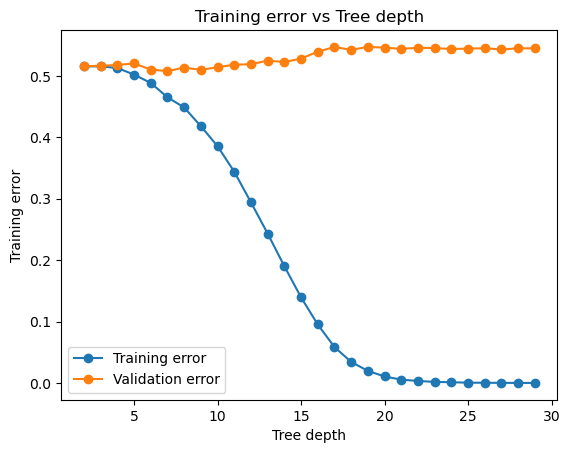

In [30]:
plt.plot(depths, train_errors, marker='o', label='Training error')
plt.plot(depths, val_errors, marker='o', label='Validation error')
plt.xlabel('Tree depth')       
plt.ylabel('Training error')   
plt.title('Training error vs Tree depth')
plt.legend()
plt.show()

In [31]:
#tree = result.best_estimator_.named_steps['model']
tree = best_tree 
ohe_features_name = ['region_references_'+region for region in class_names]
feature_names = X.columns.tolist()[:-1] + ohe_features_name

print(export_text(tree, feature_names=feature_names))

|--- region_references_Center <= 0.50
|   |--- region_references_Lombardia <= 0.50
|   |   |--- year <= -0.49
|   |   |   |--- aggressiveness <= -1.07
|   |   |   |   |--- relative_popularity <= -1.77
|   |   |   |   |   |--- tokens_per_sent <= -0.51
|   |   |   |   |   |   |--- bpm <= -0.88
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- bpm >  -0.88
|   |   |   |   |   |   |   |--- class: 3
|   |   |   |   |   |--- tokens_per_sent >  -0.51
|   |   |   |   |   |   |--- class: 4
|   |   |   |   |--- relative_popularity >  -1.77
|   |   |   |   |   |--- pitch <= 0.95
|   |   |   |   |   |   |--- loudness <= -2.66
|   |   |   |   |   |   |   |--- n_tokens <= -1.15
|   |   |   |   |   |   |   |   |--- class: 2
|   |   |   |   |   |   |   |--- n_tokens >  -1.15
|   |   |   |   |   |   |   |   |--- pitch <= 0.56
|   |   |   |   |   |   |   |   |   |--- class: 5
|   |   |   |   |   |   |   |   |--- pitch >  0.56
|   |   |   |   |   |   |   |   |   |--- class: 3
|   |  

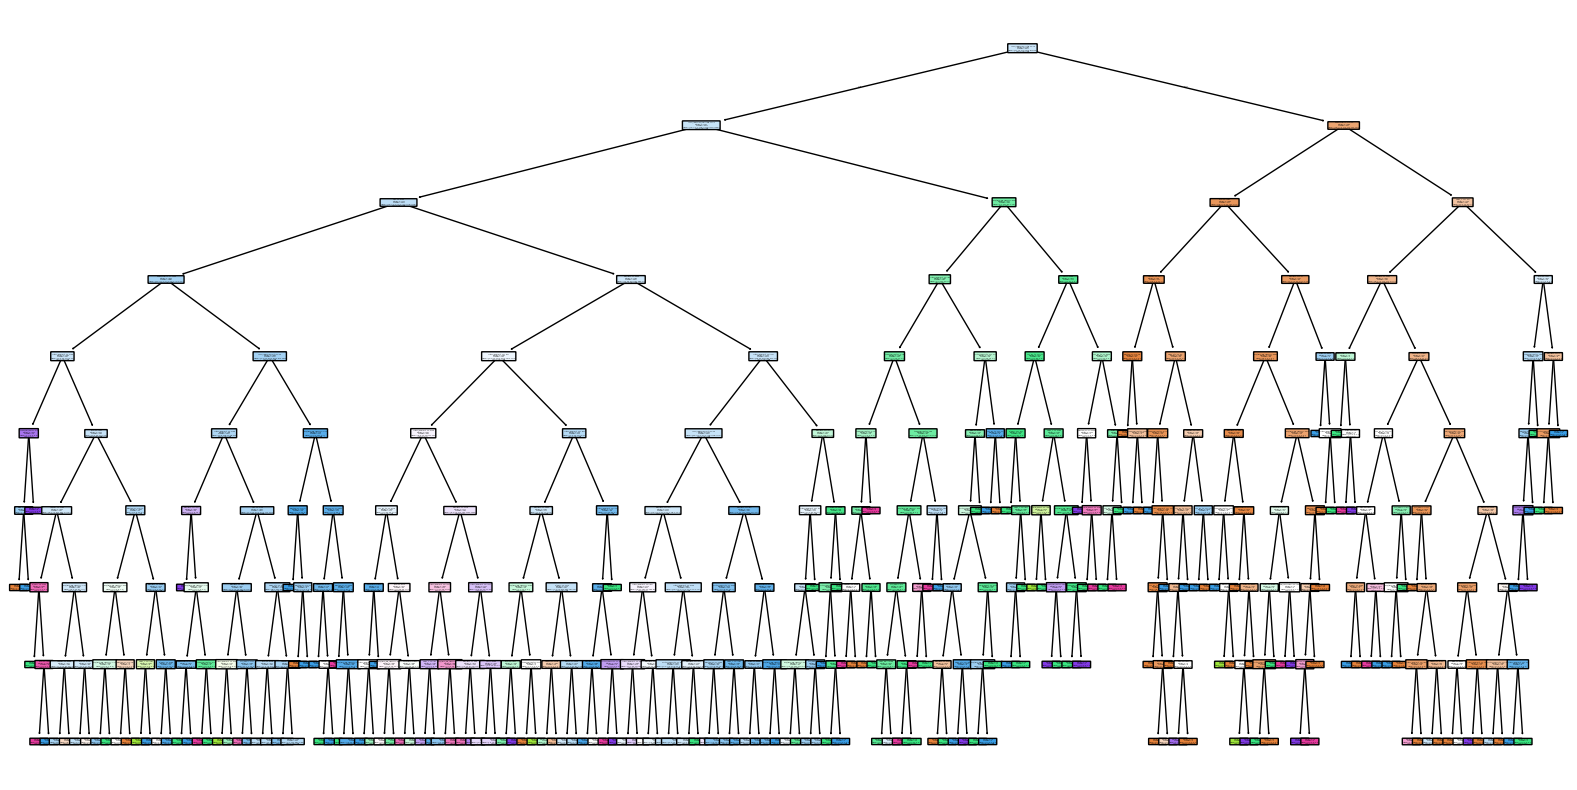

In [32]:
plt.figure(figsize=(20,10))
plot_tree(
    tree,
    feature_names=feature_names,
    class_names=le.classes_,   
    filled=True,
    rounded=True
)
plt.show()

In [33]:
importances = pd.Series(tree.feature_importances_, index=feature_names)
importances.sort_values(ascending=False)

relative_popularity            0.178395
region_references_Center       0.160158
popularity                     0.137806
region_references_Lombardia    0.072770
year                           0.063030
avg_token_per_clause           0.050166
aggressiveness                 0.033429
pitch                          0.031236
region_references_North        0.030590
loudness                       0.026927
spectral_complexity            0.024650
flux                           0.022600
tokens_per_sent                0.022237
duration_sec                   0.022071
char_per_tok                   0.019912
swear_IT                       0.015712
song_age                       0.014791
centroid                       0.014696
rolloff                        0.011106
swear_ratio                    0.011030
n_tokens                       0.010216
explicit                       0.007560
flatness                       0.005208
lexical_density                0.004451
bpm                            0.004089


Training and evaluating GBM

In [51]:
import lightgbm as lgb

gb = lgb.LGBMClassifier(
    objective='multiclass',
    n_jobs=2,
    random_state=seed,
    verbose=-1
)

param_grid = {
    'num_leaves': [80],
    'max_depth': [-1],
    'learning_rate': [0.1],
    'n_estimators': [1200],
    'min_child_samples': [7],
    'min_gain_to_split':[0.0],
    'subsample': [0.7],
    'colsample_bytree': [0.9]
}

grid = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv = stratKFold,
    n_jobs=4,
    return_train_score = True,
    scoring = ['balanced_accuracy','accuracy','f1_weighted'],
    refit='balanced_accuracy' 
)

result = grid.fit(X_train,y_train)

/home/r/miniconda3/envs/dmenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/r/miniconda3/envs/dmenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/r/miniconda3/envs/dmenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/r/miniconda3/envs/dmenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/r/miniconda3/envs/dmenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier wa

In [ ]:
df = pd.DataFrame(result.cv_results_)
df[['mean_test_accuracy','mean_test_f1_weighted','mean_test_balanced_accuracy']]

,mean_test_accuracy,mean_test_f1_weighted,mean_test_balanced_accuracy
0,0.650403,0.638694,0.519007


In [ ]:
print(f"Result: {result.best_score_}, best hyperparameters: {result.best_params_}")

Result: 0.5190071566470691, best model: LGBMClassifier(colsample_bytree=0.9, min_child_samples=7, min_gain_to_split=0.0,
               n_estimators=1200, n_jobs=2, num_leaves=80,
               objective='multiclass', random_state=42, subsample=0.7,
               verbose=-1), best hyperparameters: {'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 7, 'min_gain_to_split': 0.0, 'n_estimators': 1200, 'num_leaves': 80, 'subsample': 0.7}


Final model and test set score

In [46]:
from sklearn.metrics import balanced_accuracy_score

final_lgbm = lgb.LGBMClassifier(
    num_leaves=80,
    max_depth=-1,
    learning_rate=0.1,
    n_estimators=1200,
    min_child_samples=7,
    subsample=0.7,
    colsample_bytree=0.9,
    verbose=-1
)

final_lgbm.fit(X_train,y_train)

y_pred = final_lgbm.predict(X_test)
print(f"Final test score: {balanced_accuracy_score(y_test,y_pred)}")

/home/r/miniconda3/envs/dmenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Final test score: 0.5650825981829113


In [47]:
from sklearn.metrics import accuracy_score, f1_score
print(f"Final accuracy test score: {accuracy_score(y_test,y_pred)}")
print(f"Final F1 test score: {f1_score(y_test,y_pred,average='weighted')}")

Final accuracy test score: 0.6762342135476463
Final F1 test score: 0.6688005944666002


In [48]:
fi = pd.Series(final_lgbm.feature_importances_, index=feature_names)
fi.sort_values(ascending=False).head(34)

popularity                     13633
relative_popularity            12400
duration_sec                   10387
tokens_per_sent                10187
avg_token_per_clause            9967
pitch                           9949
loudness                        9824
lexical_density                 9732
flux                            9664
char_per_tok                    9597
spectral_complexity             9552
flatness                        9534
n_tokens                        9529
bpm                             9323
centroid                        9157
rolloff                         8279
swear_ratio                     8140
year                            8116
aggressiveness                  7142
song_age                        2982
swear_IT                        2839
explicit                        1932
swear_EN                        1114
has_collaboration               1041
region_references_Campania       544
region_references_Lombardia      524
region_references_Lazio          518
r

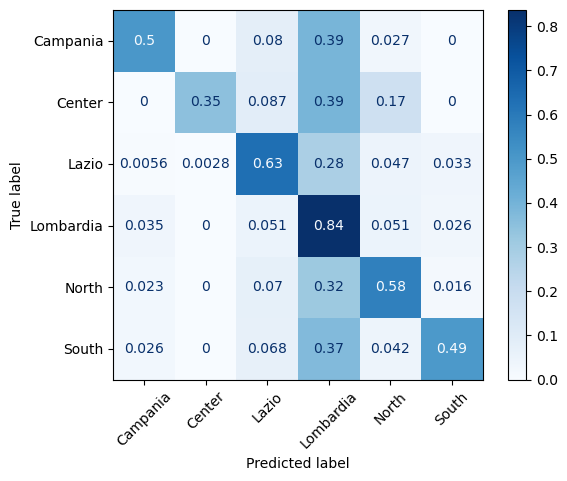

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
 
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred, normalize='true')
class_names = le.classes_  
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(cmap='Blues', xticks_rotation=45)